In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)
library_path

PosixPath('/mnt/DataVol/Beratungen/Yurttas/survival/src')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [3]:
# load data
DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"

df = pd.read_csv(f"{DATA_PATH}/all_data.csv", sep="\t")

In [4]:
cols_to_use = ["Sex", "Age", "Tumor", "CC", "PreOP CTx", "Thermoablation", "sPCI", "pPCI"]
df = df[cols_to_use].copy()

In [5]:
# data wrangling
df['Sex'] = df['Sex']-1
df['PreOP CTx'] = df['PreOP CTx'].apply(lambda x: 1 if x >= 1 else x)

keep_tumor = [1, 5, 4, 6, 7, 3, 2]  # remove 8 if you decide to drop it

# Filter rows
df = df[df["Tumor"].isin(keep_tumor)].copy()
df['Tumor'] = df['Tumor'].apply(lambda x: f"type_{x}")

df = df[(df['CC']==0) | (df['CC']==1)].reset_index(drop=True)  # keep only CC0 and CC1

In [6]:
# --- 1. Rename columns ---
df = df.rename(columns={
    "PreOP CTx" : "PreOP_CTx",
})

In [7]:
# --- 5. One-hot encode Tumor (most frequent as reference) ---
# Tumor "1" (n=122) is the natural reference category
df = pd.get_dummies(df, columns=["Tumor"], drop_first=False, dtype=int)
df = df.drop(columns=["Tumor_type_1"], inplace=False)  # explicitly set Tumor_1 as reference

# --- 6. Create outcome variables ---
df["raw_diff"] = df["sPCI"] - df["pPCI"]
df["abs_diff"] = np.abs(df["raw_diff"])


In [8]:
feature_cols = [
    'Sex', 'Age', 'CC', 'PreOP_CTx', 'Thermoablation', 'Tumor_type_2', 'Tumor_type_3', 'Tumor_type_4', 'Tumor_type_5',
       'Tumor_type_6', 'Tumor_type_7'
]

X     = df[feature_cols]
y_raw = df["raw_diff"]
y_abs = df["abs_diff"]

print(f"Final feature matrix: {X.shape}")

Final feature matrix: (409, 11)


In [9]:
X = sm.add_constant(X)

## Quantile Regression at the Median (q = 0.5)

Models the **median** of `raw_diff` — no distributional assumption on residuals.

In [10]:
import statsmodels.formula.api as smf

qr50 = smf.quantreg(
    "raw_diff ~ Sex + Age + CC + PreOP_CTx + Thermoablation + "
    "Tumor_type_2 + Tumor_type_3 + Tumor_type_4 + Tumor_type_5 + Tumor_type_6 + Tumor_type_7",
    data=df
).fit(q=0.5)

print(qr50.summary())

                         QuantReg Regression Results                          
Dep. Variable:               raw_diff   Pseudo R-squared:               0.1894
Model:                       QuantReg   Bandwidth:                       3.322
Method:                 Least Squares   Sparsity:                        11.89
Date:                Wed, 13 May 2026   No. Observations:                  409
Time:                        14:29:39   Df Residuals:                      397
                                        Df Model:                           11
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          7.3800      1.786      4.133      0.000       3.870      10.890
Sex               -0.2200      0.675     -0.326      0.745      -1.547       1.107
Age               -0.0200      0.025     -0.788      0.431      -0.070       0.030
CC                 5.2200      0

## Quantile Process: q = 0.25, 0.50, 0.75, 0.90

Fit the model across multiple quantiles to see how effects change across the distribution of `raw_diff`.

In [11]:
formula = (
    "raw_diff ~ Sex + Age + CC + PreOP_CTx + Thermoablation + "
    "Tumor_type_2 + Tumor_type_3 + Tumor_type_4 + Tumor_type_5 + Tumor_type_6 + Tumor_type_7"
)

quantiles = [0.25, 0.50, 0.75, 0.90]
qr_models = {q: smf.quantreg(formula, data=df).fit(q=q) for q in quantiles}

# Summary table: coefficients and p-values across quantiles
predictors = qr_models[0.5].params.index.tolist()

print(f"{'Predictor':<22}", end="")
for q in quantiles:
    print(f"  {'q='+str(q):<20}", end="")
print()
print("-" * (22 + 22 * len(quantiles)))

for pred in predictors:
    print(f"{pred:<22}", end="")
    for q in quantiles:
        m   = qr_models[q]
        coef = m.params[pred]
        pval = m.pvalues[pred]
        sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
        print(f"  {coef:+.3f} p={pval:.3f} {sig:<4}", end="")
    print()

Predictor               q=0.25                q=0.5                 q=0.75                q=0.9               
--------------------------------------------------------------------------------------------------------------
Intercept               +4.466 p=0.003 **    +7.380 p=0.000 ***   +7.000 p=0.005 **    +8.950 p=0.006 **  
Sex                     -0.224 p=0.714       -0.220 p=0.745       -1.000 p=0.264       -2.400 p=0.034 *   
Age                     -0.034 p=0.120       -0.020 p=0.431       -0.000 p=1.000       +0.025 p=0.558     
CC                      +3.603 p=0.000 ***   +5.220 p=0.000 ***   +9.000 p=0.000 ***   +9.100 p=0.000 *** 
PreOP_CTx               -0.672 p=0.353       -1.900 p=0.017 *     -1.000 p=0.350       -0.600 p=0.643     
Thermoablation          -1.397 p=0.042 *     -2.080 p=0.005 **    -1.000 p=0.297       -0.275 p=0.797     
Tumor_type_2            -0.397 p=0.761       -0.357 p=0.805       +1.000 p=0.594       -0.250 p=0.909     
Tumor_type_3            -0.06

## Coefficient Plot across Quantiles

Visualise how each predictor's effect evolves from lower to upper quantiles, with 95% confidence bands.

/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


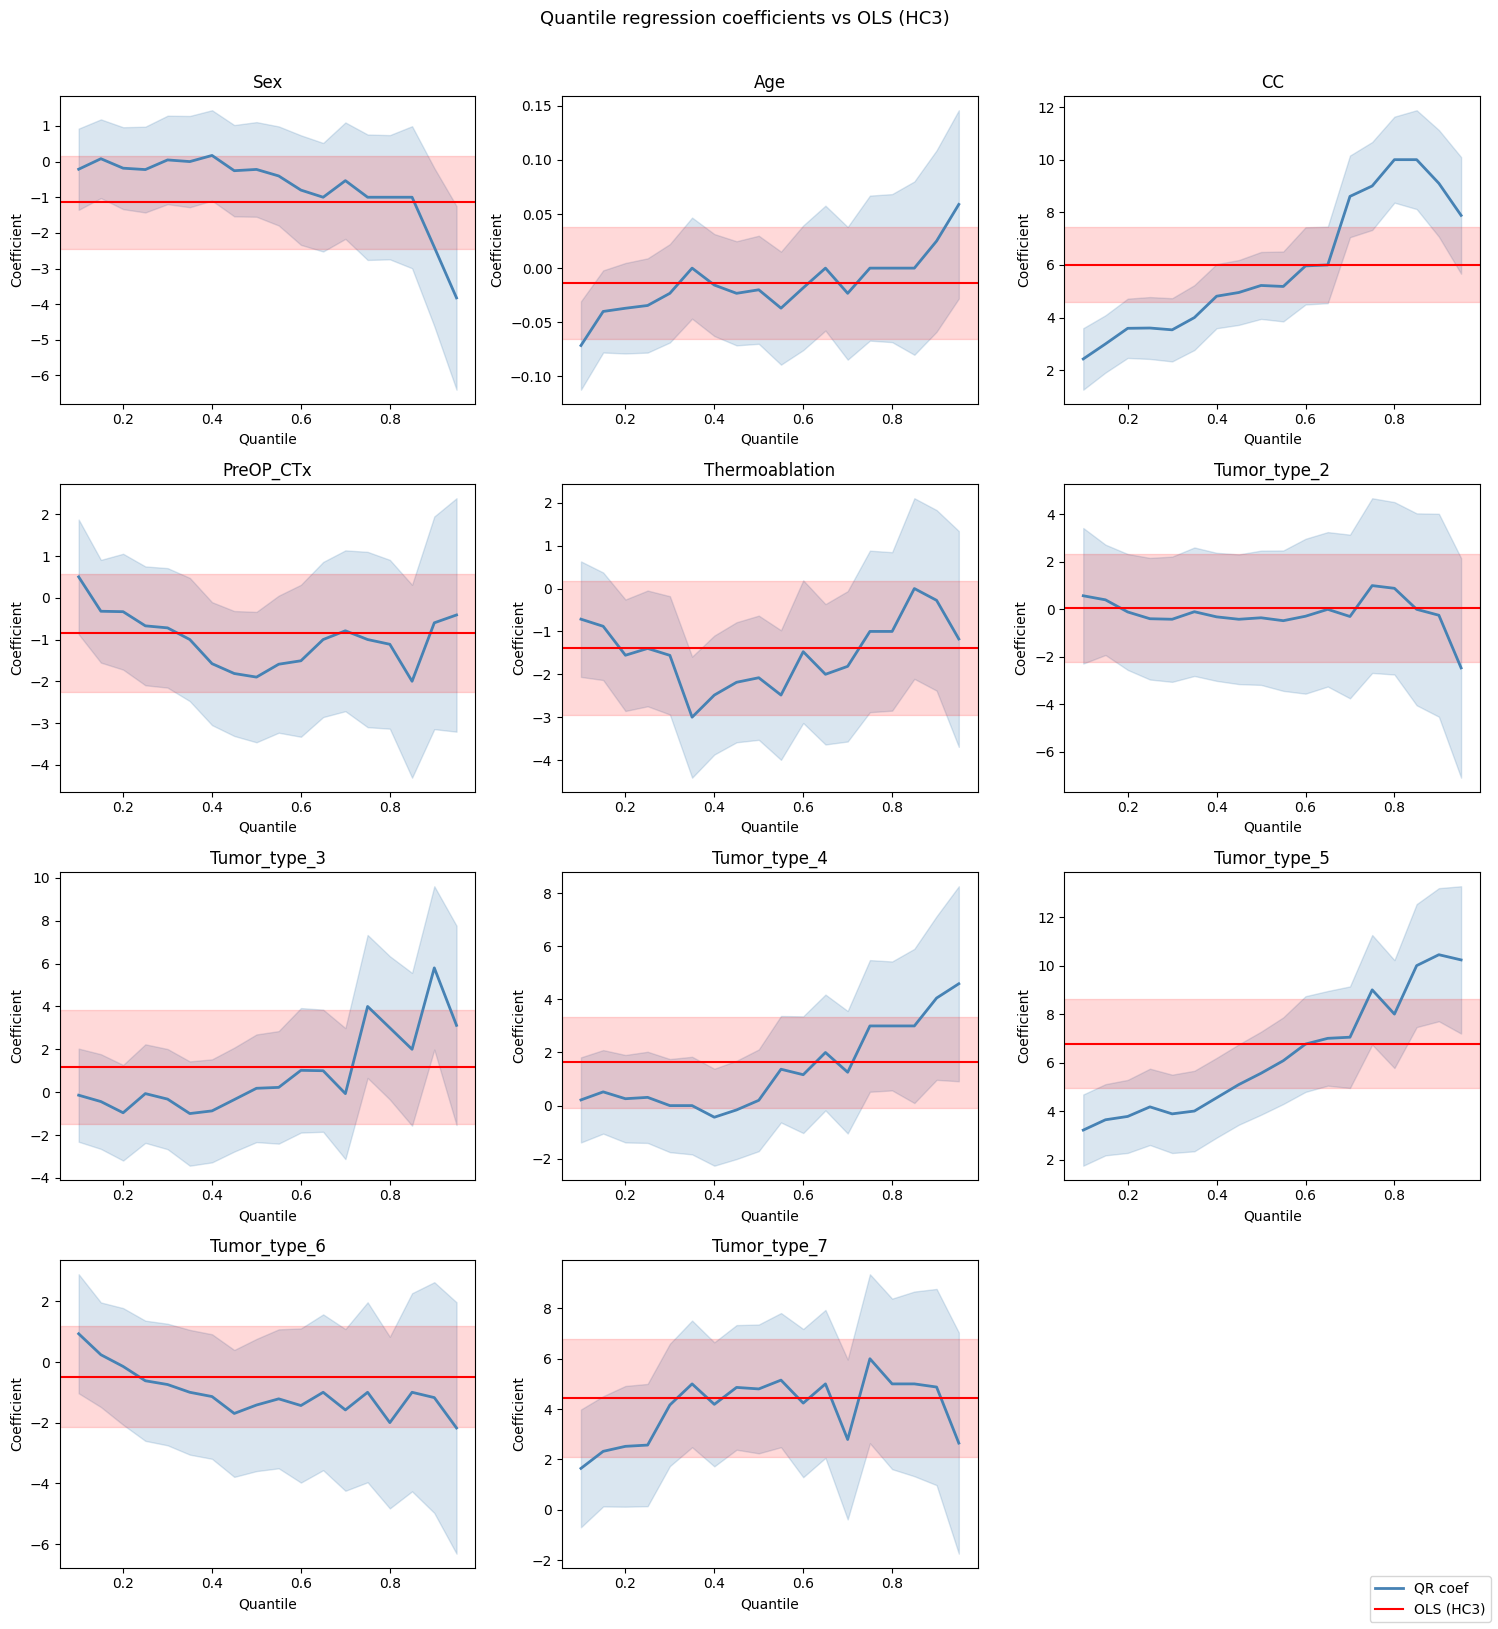

In [12]:
plot_quantiles = np.arange(0.1, 0.96, 0.05)
plot_models    = {q: smf.quantreg(formula, data=df).fit(q=q) for q in plot_quantiles}

# OLS reference line (with HC3 SEs)
ols_model  = smf.ols(formula, data=df).fit()
ols_robust = ols_model.get_robustcov_results(cov_type="HC3")

# get_robustcov_results returns ndarray params/conf_int, so reattach predictor names
ols_params = pd.Series(ols_robust.params, index=ols_model.params.index)
ols_ci = pd.DataFrame(ols_robust.conf_int(), index=ols_model.params.index, columns=[0, 1])

plot_predictors = [p for p in predictors if p != "Intercept"]
ncols = 3
nrows = -(-len(plot_predictors) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, pred in zip(axes, plot_predictors):
    coefs = [plot_models[q].params[pred]  for q in plot_quantiles]
    ci_lo = [plot_models[q].conf_int().loc[pred, 0] for q in plot_quantiles]
    ci_hi = [plot_models[q].conf_int().loc[pred, 1] for q in plot_quantiles]

    ax.fill_between(plot_quantiles, ci_lo, ci_hi, alpha=0.2, color="steelblue")
    ax.plot(plot_quantiles, coefs, color="steelblue", lw=2, label="QR coef")
    # OLS reference
    ols_coef = ols_params[pred]
    ols_lo   = ols_ci.loc[pred, 0]
    ols_hi   = ols_ci.loc[pred, 1]
    ax.axhline(ols_coef, color="red",  linestyle="-",  lw=1.5, label="OLS (HC3)")
    ax.axhspan(ols_lo,   ols_hi,       alpha=0.15,     color="red")

    ax.set_title(pred)
    ax.set_xlabel("Quantile")
    ax.set_ylabel("Coefficient")

# hide unused axes
for ax in axes[len(plot_predictors):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=10)
plt.suptitle("Quantile regression coefficients vs OLS (HC3)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


## Pseudo-R² across Quantiles

The quantile regression pseudo-R² (Koenker & Machado, 1999) measures goodness of fit at each quantile — analogous to R² but for the quantile loss function.

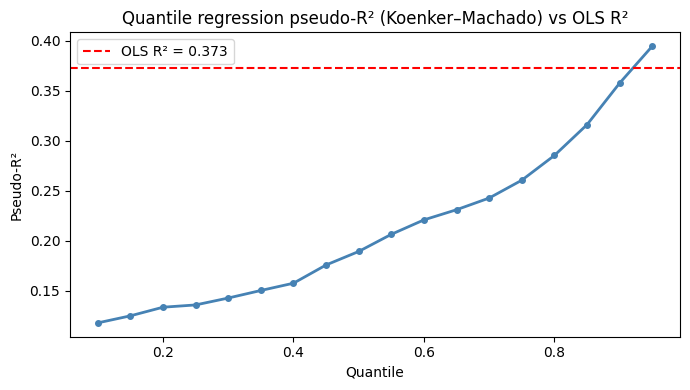


Pseudo-R² at selected quantiles:
  q=0.25  pseudo-R² = 0.1359
  q=0.50  pseudo-R² = 0.1894
  q=0.75  pseudo-R² = 0.2606
  q=0.90  pseudo-R² = 0.3577


In [13]:
pseudo_r2 = [plot_models[q].prsquared for q in plot_quantiles]

plt.figure(figsize=(7, 4))
plt.plot(plot_quantiles, pseudo_r2, color="steelblue", lw=2, marker="o", markersize=4)
plt.axhline(ols_model.rsquared, color="red", linestyle="--", label=f"OLS R² = {ols_model.rsquared:.3f}")
plt.xlabel("Quantile")
plt.ylabel("Pseudo-R²")
plt.title("Quantile regression pseudo-R² (Koenker–Machado) vs OLS R²")
plt.legend()
plt.tight_layout()
plt.show()

print("\nPseudo-R² at selected quantiles:")
for q in [0.25, 0.50, 0.75, 0.90]:
    print(f"  q={q:.2f}  pseudo-R² = {qr_models[q].prsquared:.4f}")

## Diagnostics

### Diag 1 — Residual Sign Proportions

At quantile *q*, exactly *q × 100%* of residuals should be negative (this is the defining property of quantile regression). Deviation indicates numerical convergence issues.

In [14]:
print(f"{'Quantile':>10}  {'Expected %neg':>14}  {'Actual %neg':>12}  {'N neg':>6}  {'OK?'}")
print("-" * 55)
for q in quantiles:
    resid_q = qr_models[q].resid
    pct_neg  = (resid_q < 0).mean()
    ok       = "✓" if abs(pct_neg - q) < 0.05 else "✗"
    print(f"  q={q:.2f}    {q*100:>10.1f}%    {pct_neg*100:>10.1f}%    {(resid_q<0).sum():>5}    {ok}")

  Quantile   Expected %neg   Actual %neg   N neg  OK?
-------------------------------------------------------
  q=0.25          25.0%          25.7%      105    ✓
  q=0.50          50.0%          50.6%      207    ✓
  q=0.75          75.0%          73.8%      302    ✓
  q=0.90          90.0%          88.8%      363    ✓


### Diag 2 — Residuals vs Fitted

Check for systematic patterns or heteroskedasticity in residuals at each quantile.

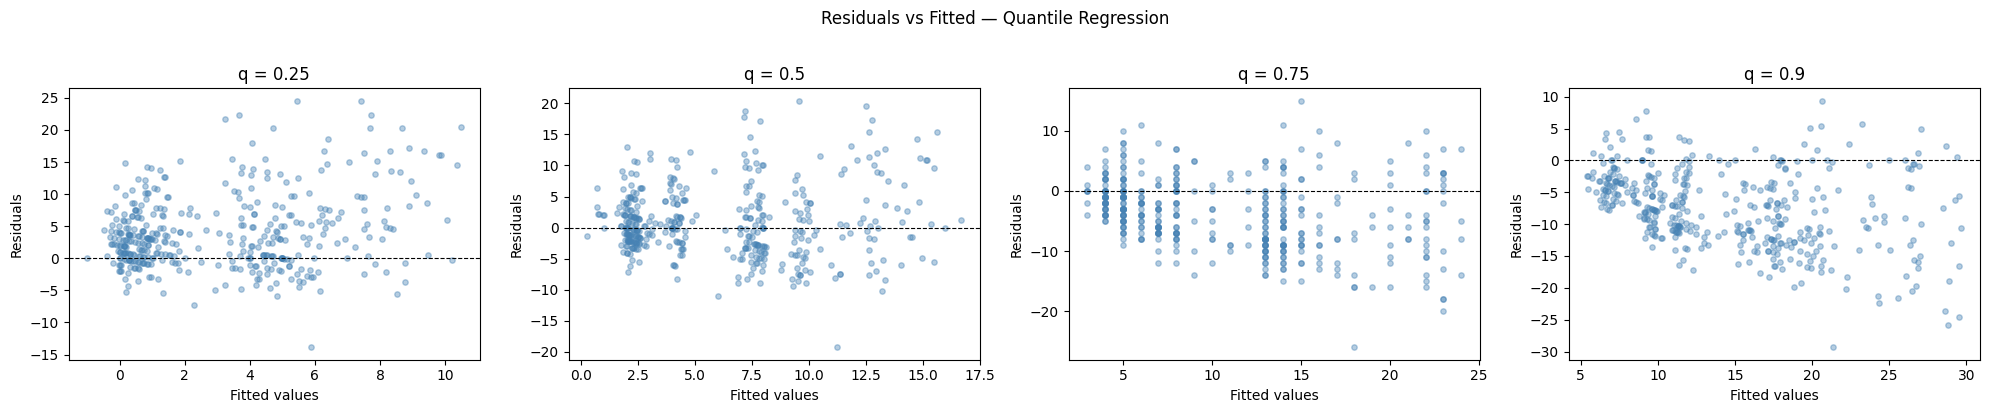

In [15]:
fig, axes = plt.subplots(1, len(quantiles), figsize=(5 * len(quantiles), 4), sharey=False)

for ax, q in zip(axes, quantiles):
    m      = qr_models[q]
    resid  = m.resid
    fitted = m.fittedvalues
    ax.scatter(fitted, resid, alpha=0.4, s=15, color="steelblue")
    ax.axhline(0, color="black", linestyle="--", lw=0.8)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title(f"q = {q}")

plt.suptitle("Residuals vs Fitted — Quantile Regression", y=1.02)
plt.tight_layout()
plt.show()

### Diag 3 — Residuals vs Predictors (Spearman)

Spearman correlations between residuals and each predictor should be ~0. Any significant correlation suggests a missed non-linear term or an omitted variable.

In [16]:
from scipy import stats

print(f"{'Predictor':<22}", end="")
for q in quantiles:
    print(f"  {'q='+str(q):<18}", end="")
print()
print("-" * (22 + 20 * len(quantiles)))

for col in feature_cols:
    print(f"{col:<22}", end="")
    for q in quantiles:
        resid_q = qr_models[q].resid
        r, p    = stats.spearmanr(df[col], resid_q)
        sig     = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        print(f"  rho={r:+.2f} p={p:.3f}{sig:<4}", end="")
    print()

Predictor               q=0.25              q=0.5               q=0.75              q=0.9             
------------------------------------------------------------------------------------------------------
Sex                     rho=-0.04 p=0.430      rho=-0.02 p=0.733      rho=-0.00 p=0.929      rho=+0.06 p=0.204    
Age                     rho=+0.02 p=0.762      rho=+0.00 p=0.955      rho=+0.00 p=0.980      rho=-0.07 p=0.141    
CC                      rho=+0.15 p=0.003**    rho=+0.00 p=0.991      rho=-0.24 p=0.000***   rho=-0.22 p=0.000*** 
PreOP_CTx               rho=+0.00 p=0.950      rho=+0.05 p=0.359      rho=-0.07 p=0.138      rho=-0.12 p=0.018*   
Thermoablation          rho=-0.08 p=0.124      rho=+0.02 p=0.635      rho=+0.05 p=0.319      rho=+0.01 p=0.784    
Tumor_type_2            rho=-0.00 p=0.961      rho=+0.00 p=0.974      rho=-0.01 p=0.773      rho=+0.05 p=0.329    
Tumor_type_3            rho=+0.00 p=0.929      rho=+0.01 p=0.843      rho=-0.08 p=0.112      rho=-0.14 p

### Diag 4 — Bootstrap CIs vs Asymptotic SEs (median model)

The default SEs in `quantreg` use a kernel-based sparsity estimator whose bandwidth choice can affect results. Bootstrap CIs are a distribution-free alternative. Disagreement between the two flags predictors where the sparsity estimator is unreliable.

In [17]:
np.random.seed(42)
n_boot = 2000
n      = len(df)
param_names = qr50.params.index.tolist()
boot_params = np.zeros((n_boot, len(param_names)))

for i in range(n_boot):
    idx   = np.random.choice(n, size=n, replace=True)
    b     = smf.quantreg(formula, data=df.iloc[idx]).fit(q=0.5, disp=False)
    boot_params[i] = b.params.values

boot_se = boot_params.std(axis=0)
ci_lo   = np.percentile(boot_params, 2.5,  axis=0)
ci_hi   = np.percentile(boot_params, 97.5, axis=0)

print(f"{'Predictor':<22} {'coef':>7}  {'asym_SE':>8}  {'boot_SE':>8}  {'95% CI (bootstrap)'}")
print("-" * 75)
for name, coef, ase, bse, lo, hi in zip(
        param_names, qr50.params, qr50.bse, boot_se, ci_lo, ci_hi):
    sig = "*" if lo > 0 or hi < 0 else ""
    print(f"{name:<22} {coef:+7.3f}  {ase:8.3f}  {bse:8.3f}  [{lo:+.3f}, {hi:+.3f}] {sig}")

/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: Ite

Predictor                 coef   asym_SE   boot_SE  95% CI (bootstrap)
---------------------------------------------------------------------------
Intercept               +7.380     1.786     1.790  [+4.000, +10.942] *
Sex                     -0.220     0.675     0.691  [-1.773, +1.000] 
Age                     -0.020     0.025     0.025  [-0.070, +0.026] 
CC                      +5.220     0.647     0.927  [+3.269, +7.000] *
PreOP_CTx               -1.900     0.794     0.780  [-3.000, -0.000] *
Thermoablation          -2.080     0.737     0.901  [-4.000, -0.398] *
Tumor_type_2            -0.357     1.440     1.390  [-3.000, +2.637] 
Tumor_type_3            +0.180     1.278     1.547  [-2.414, +3.634] 
Tumor_type_4            +0.199     0.974     1.048  [-1.333, +2.393] 
Tumor_type_5            +5.560     0.871     1.118  [+3.256, +7.889] *
Tumor_type_6            -1.420     1.108     0.895  [-3.000, +0.582] 
Tumor_type_7            +4.800     1.302     1.658  [+1.000, +7.677] *


/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


### Diag 5 — Symmetry Test (q = 0.25 vs q = 0.75)

Tests whether the effect of each predictor at the lower and upper quartile are equal. A significant difference means the effect is **asymmetric** — larger in one tail than the other. Uses a Wald-type test based on bootstrap samples.

In [18]:
np.random.seed(0)
n_boot2 = 2000
boot_25  = np.zeros((n_boot2, len(param_names)))
boot_75  = np.zeros((n_boot2, len(param_names)))

for i in range(n_boot2):
    idx = np.random.choice(n, size=n, replace=True)
    sub = df.iloc[idx]
    boot_25[i] = smf.quantreg(formula, data=sub).fit(q=0.25, disp=False).params.values
    boot_75[i] = smf.quantreg(formula, data=sub).fit(q=0.75, disp=False).params.values

diff        = boot_75 - boot_25
diff_mean   = diff.mean(axis=0)
diff_se     = diff.std(axis=0)
diff_ci_lo  = np.percentile(diff, 2.5,  axis=0)
diff_ci_hi  = np.percentile(diff, 97.5, axis=0)

print("Symmetry test: effect at q=0.75 minus effect at q=0.25")
print("A CI excluding zero means the effect differs between tails.\n")
print(f"{'Predictor':<22} {'Δcoef':>7}  {'boot_SE':>8}  {'95% CI of Δ':<24}  {'Asymmetric?'}")
print("-" * 75)
for pname, dm, ds, lo, hi in zip(param_names, diff_mean, diff_se, diff_ci_lo, diff_ci_hi):
    asym = "YES *" if lo > 0 or hi < 0 else ""
    print(f"{pname:<22} {dm:+7.3f}  {ds:8.3f}  [{lo:+.3f}, {hi:+.3f}]          {asym}")

/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: Ite

Symmetry test: effect at q=0.75 minus effect at q=0.25
A CI excluding zero means the effect differs between tails.

Predictor                Δcoef   boot_SE  95% CI of Δ               Asymmetric?
---------------------------------------------------------------------------
Intercept               +4.509     3.291  [-1.800, +11.147]          
Sex                     -0.813     1.100  [-3.054, +1.161]          
Age                     +0.022     0.050  [-0.074, +0.120]          
CC                      +5.039     1.532  [+1.937, +7.875]          YES *
PreOP_CTx               -0.680     1.253  [-3.406, +1.546]          
Thermoablation          -0.026     1.307  [-2.806, +2.340]          
Tumor_type_2            +0.361     2.113  [-3.649, +4.683]          
Tumor_type_3            +1.963     2.697  [-2.544, +7.488]          
Tumor_type_4            +1.929     1.623  [-1.223, +4.930]          
Tumor_type_5            +3.939     1.786  [+0.835, +7.884]          YES *
Tumor_type_6            -1.

### Diag 6 — Quantile Crossing

Checks whether predicted quantiles are properly ordered (q25 ≤ q50 ≤ q75 ≤ q90). Crossing indicates model instability for individual observations.

In [19]:
# Build prediction matrix from fitted models
preds_df = pd.DataFrame(index=df.index)
for q in quantiles:
    preds_df[f"q{int(q*100)}"] = qr_models[q].predict(df)

# Pairwise crossing checks
cross_25_50 = preds_df["q25"] > preds_df["q50"]
cross_50_75 = preds_df["q50"] > preds_df["q75"]
cross_75_90 = preds_df["q75"] > preds_df["q90"]

any_crossing_full = cross_25_50 | cross_50_75 | cross_75_90

# Report
print("\nQuantile Crossing Diagnostics (full model)")
print("-" * 40)
print(f"q25 > q50: {cross_25_50.mean():.3%}")
print(f"q50 > q75: {cross_50_75.mean():.3%}")
print(f"q75 > q90: {cross_75_90.mean():.3%}")
print(f"ANY crossing: {any_crossing_full.mean():.3%}")



Quantile Crossing Diagnostics (full model)
----------------------------------------
q25 > q50: 0.000%
q50 > q75: 0.000%
q75 > q90: 0.000%
ANY crossing: 0.000%


# Reduced Model — Age Excluded

Age was not significant at any quantile (all p > 0.10). The following cells repeat the full analysis without Age as a predictor.

In [20]:
r_feature_cols = [
    'Sex', 'CC', 'PreOP_CTx', 'Thermoablation',
    'Tumor_type_2', 'Tumor_type_3', 'Tumor_type_4',
    'Tumor_type_5', 'Tumor_type_6', 'Tumor_type_7'
]

r_formula = (
    "raw_diff ~ Sex + CC + PreOP_CTx + Thermoablation + "
    "Tumor_type_2 + Tumor_type_3 + Tumor_type_4 + Tumor_type_5 + Tumor_type_6 + Tumor_type_7"
)

print(f"Predictors: {r_feature_cols}")

Predictors: ['Sex', 'CC', 'PreOP_CTx', 'Thermoablation', 'Tumor_type_2', 'Tumor_type_3', 'Tumor_type_4', 'Tumor_type_5', 'Tumor_type_6', 'Tumor_type_7']


## Quantile Regression at the Median (q = 0.5)

In [21]:
r_qr50 = smf.quantreg(r_formula, data=df).fit(q=0.5)
print(r_qr50.summary())

                         QuantReg Regression Results                          
Dep. Variable:               raw_diff   Pseudo R-squared:               0.1891
Model:                       QuantReg   Bandwidth:                       3.492
Method:                 Least Squares   Sparsity:                        11.88
Date:                Wed, 13 May 2026   No. Observations:                  409
Time:                        14:33:08   Df Residuals:                      398
                                        Df Model:                           10
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          6.0000      1.106      5.423      0.000       3.825       8.175
Sex            -5.333e-07      0.674  -7.91e-07      1.000      -1.325       1.325
CC                 5.0000      0.646      7.743      0.000       3.730       6.270
PreOP_CTx         -2.0000      0

## Quantile Process: q = 0.25, 0.50, 0.75, 0.90

In [22]:
r_quantiles = [0.25, 0.50, 0.75, 0.90]
r_preds = pd.DataFrame(index=df.index)
r_qr_models = {q: smf.quantreg(r_formula, data=df).fit(q=q) for q in r_quantiles}

r_predictors = r_qr_models[0.5].params.index.tolist()

print(f"{'Predictor':<22}", end="")
for q in r_quantiles:
    print(f"  {'q='+str(q):<20}", end="")
print()
print("-" * (22 + 22 * len(r_quantiles)))

for pred in r_predictors:
    print(f"{pred:<22}", end="")
    for q in r_quantiles:
        m    = r_qr_models[q]
        coef = m.params[pred]
        pval = m.pvalues[pred]
        sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
        print(f"  {coef:+.3f} p={pval:.3f} {sig:<4}", end="")
    print()

Predictor               q=0.25                q=0.5                 q=0.75                q=0.9               
--------------------------------------------------------------------------------------------------------------
Intercept               +3.000 p=0.007 **    +6.000 p=0.000 ***   +7.000 p=0.000 ***   +10.000 p=0.000 *** 
Sex                     -0.000 p=1.000       -0.000 p=1.000       -1.000 p=0.261       -2.000 p=0.082     
CC                      +4.000 p=0.000 ***   +5.000 p=0.000 ***   +9.000 p=0.000 ***   +9.000 p=0.000 *** 
PreOP_CTx               -1.000 p=0.200       -2.000 p=0.012 *     -1.000 p=0.358       -1.000 p=0.445     
Thermoablation          -2.000 p=0.007 **    -2.000 p=0.007 **    -1.000 p=0.303       -0.000 p=1.000     
Tumor_type_2            -0.000 p=1.000       -0.000 p=1.000       +1.001 p=0.593       -1.000 p=0.640     
Tumor_type_3            -0.000 p=1.000       -0.000 p=1.000       +4.000 p=0.019 *     +6.000 p=0.002 **  
Tumor_type_4            -0.0

## Coefficient Plot across Quantiles

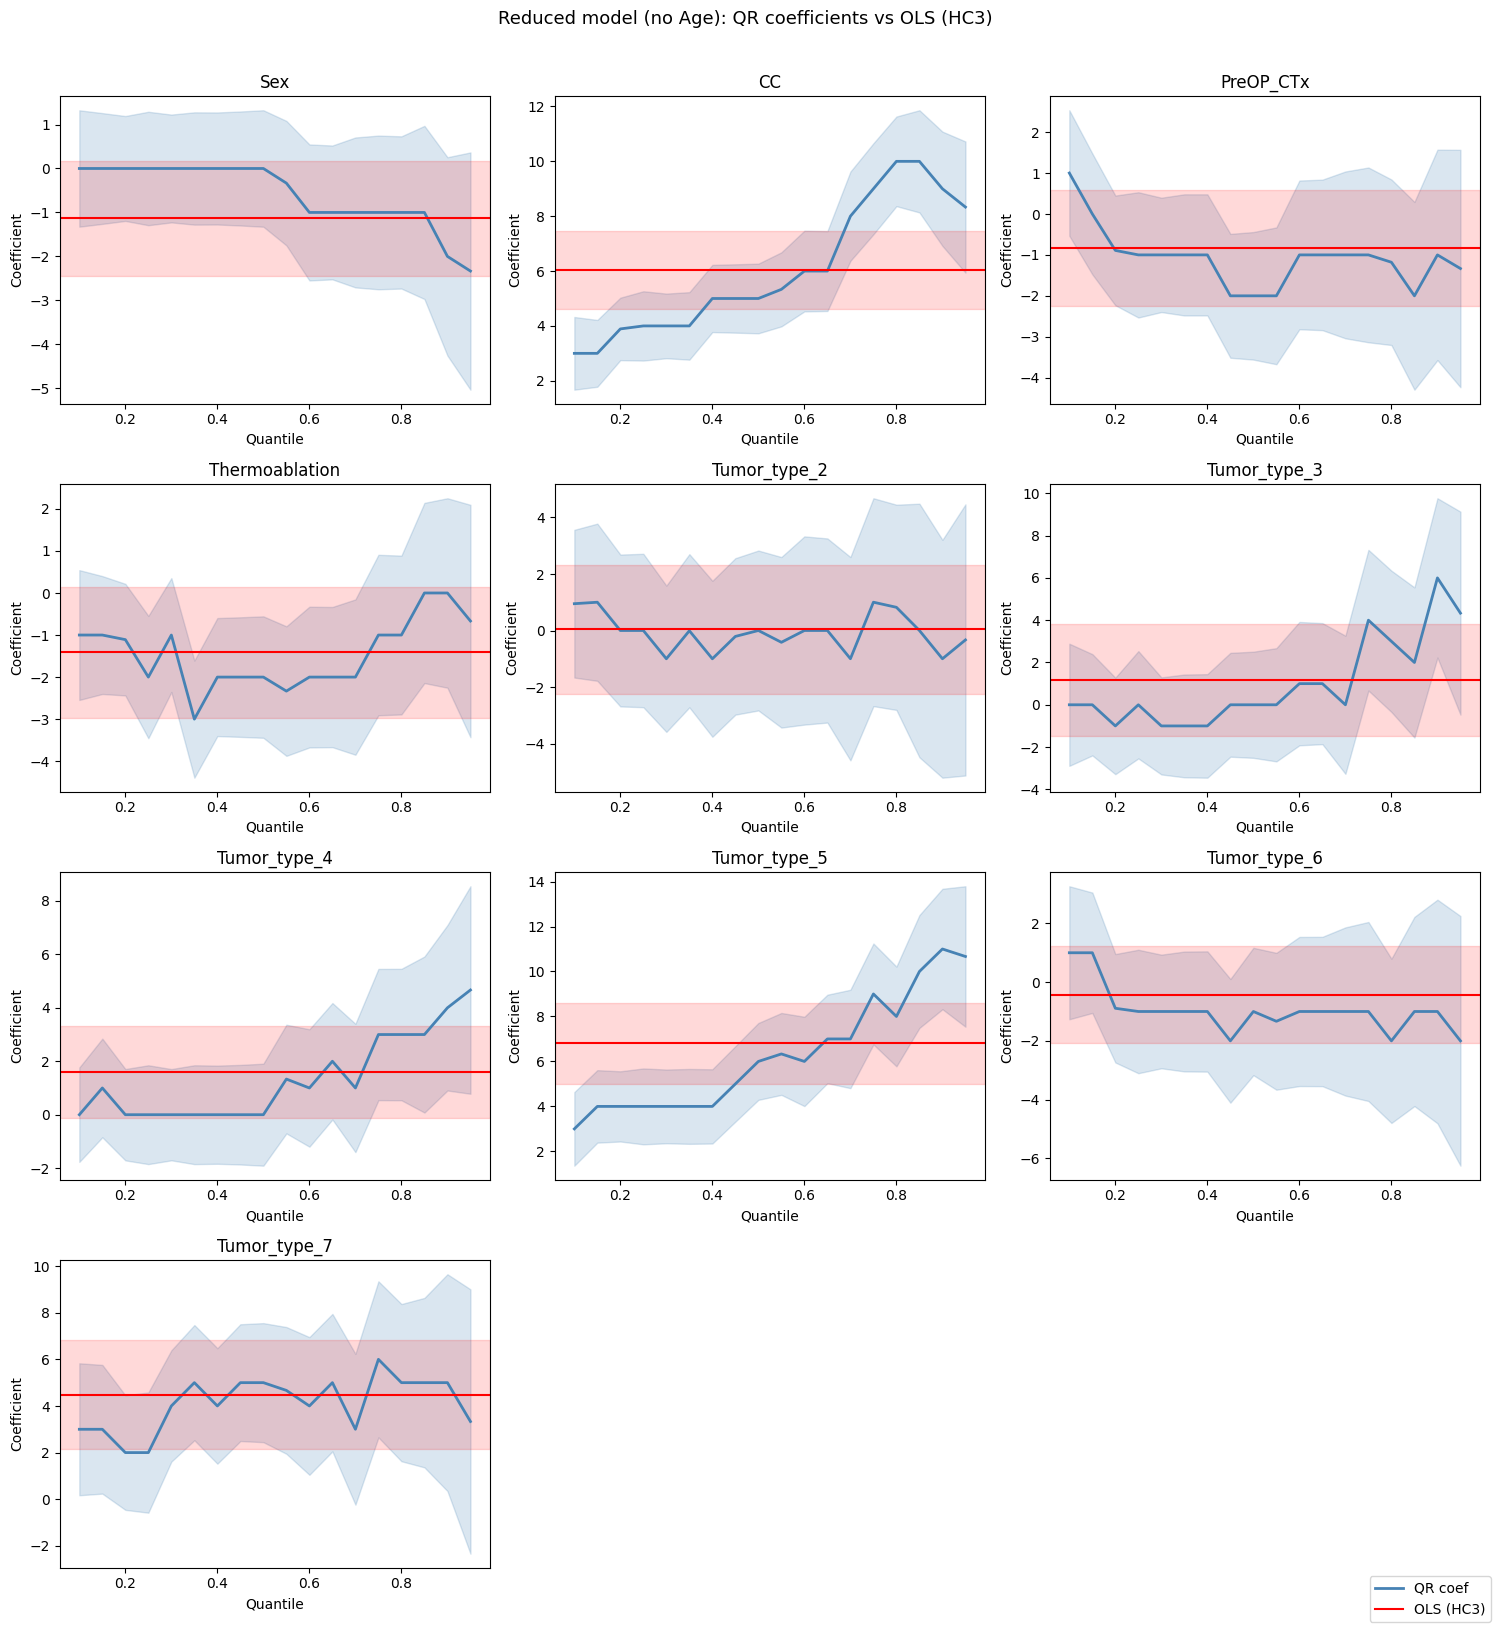

In [23]:
r_plot_quantiles = np.arange(0.1, 0.96, 0.05)
r_plot_models    = {q: smf.quantreg(r_formula, data=df).fit(q=q) for q in r_plot_quantiles}

r_ols_model  = smf.ols(r_formula, data=df).fit()
r_ols_robust = r_ols_model.get_robustcov_results(cov_type="HC3")
r_ols_params = pd.Series(r_ols_robust.params, index=r_ols_model.params.index)
r_ols_ci     = pd.DataFrame(r_ols_robust.conf_int(), index=r_ols_model.params.index, columns=[0, 1])

r_plot_predictors = [p for p in r_predictors if p != "Intercept"]
ncols = 3
nrows = -(-len(r_plot_predictors) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, pred in zip(axes, r_plot_predictors):
    coefs = [r_plot_models[q].params[pred] for q in r_plot_quantiles]
    ci_lo = [r_plot_models[q].conf_int().loc[pred, 0] for q in r_plot_quantiles]
    ci_hi = [r_plot_models[q].conf_int().loc[pred, 1] for q in r_plot_quantiles]

    ax.fill_between(r_plot_quantiles, ci_lo, ci_hi, alpha=0.2, color="steelblue")
    ax.plot(r_plot_quantiles, coefs, color="steelblue", lw=2, label="QR coef")

    ols_coef = r_ols_params[pred]
    ols_lo   = r_ols_ci.loc[pred, 0]
    ols_hi   = r_ols_ci.loc[pred, 1]
    ax.axhline(ols_coef, color="red", linestyle="-", lw=1.5, label="OLS (HC3)")
    ax.axhspan(ols_lo, ols_hi, alpha=0.15, color="red")

    ax.set_title(pred)
    ax.set_xlabel("Quantile")
    ax.set_ylabel("Coefficient")

for ax in axes[len(r_plot_predictors):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=10)
plt.suptitle("Reduced model (no Age): QR coefficients vs OLS (HC3)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Pseudo-R² across Quantiles

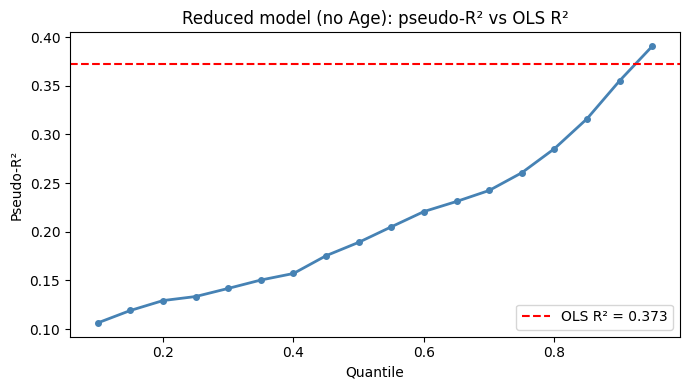


Pseudo-R² at selected quantiles:
  q=0.25  pseudo-R² = 0.1334
  q=0.50  pseudo-R² = 0.1891
  q=0.75  pseudo-R² = 0.2606
  q=0.90  pseudo-R² = 0.3552


In [24]:
r_pseudo_r2 = [r_plot_models[q].prsquared for q in r_plot_quantiles]

plt.figure(figsize=(7, 4))
plt.plot(r_plot_quantiles, r_pseudo_r2, color="steelblue", lw=2, marker="o", markersize=4)
plt.axhline(r_ols_model.rsquared, color="red", linestyle="--",
            label=f"OLS R² = {r_ols_model.rsquared:.3f}")
plt.xlabel("Quantile")
plt.ylabel("Pseudo-R²")
plt.title("Reduced model (no Age): pseudo-R² vs OLS R²")
plt.legend()
plt.tight_layout()
plt.show()

print("\nPseudo-R² at selected quantiles:")
for q in [0.25, 0.50, 0.75, 0.90]:
    print(f"  q={q:.2f}  pseudo-R² = {r_qr_models[q].prsquared:.4f}")

## Diagnostics

### Diag 1 — Residual Sign Proportions

In [25]:
print(f"{'Quantile':>10}  {'Expected %neg':>14}  {'Actual %neg':>12}  {'N neg':>6}  {'OK?'}")
print("-" * 55)
for q in r_quantiles:
    resid_q = r_qr_models[q].resid
    pct_neg = (resid_q < 0).mean()
    ok      = "✓" if abs(pct_neg - q) < 0.05 else "✗"
    print(f"  q={q:.2f}    {q*100:>10.1f}%    {pct_neg*100:>10.1f}%    {(resid_q<0).sum():>5}    {ok}")

  Quantile   Expected %neg   Actual %neg   N neg  OK?
-------------------------------------------------------
  q=0.25          25.0%          26.7%      109    ✓
  q=0.50          50.0%          51.6%      211    ✓
  q=0.75          75.0%          74.1%      303    ✓
  q=0.90          90.0%          87.5%      358    ✓


### Diag 2 — Residuals vs Fitted

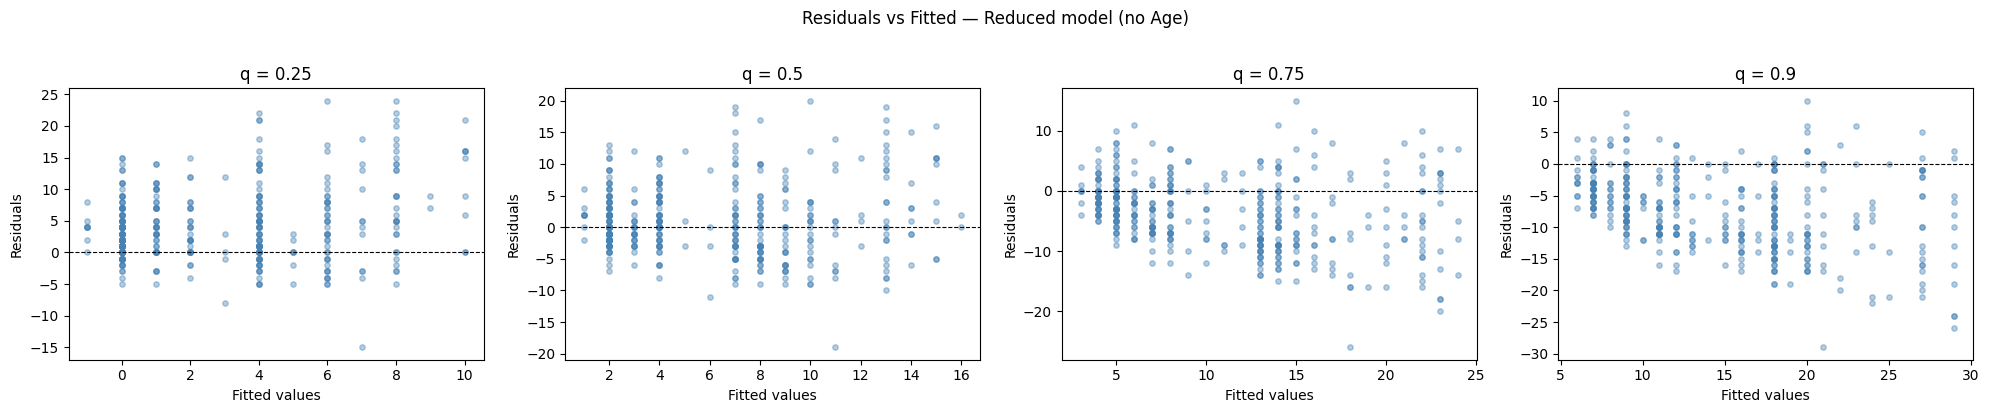

In [26]:
fig, axes = plt.subplots(1, len(r_quantiles), figsize=(5 * len(r_quantiles), 4), sharey=False)

for ax, q in zip(axes, r_quantiles):
    m      = r_qr_models[q]
    resid  = m.resid
    fitted = m.fittedvalues
    ax.scatter(fitted, resid, alpha=0.4, s=15, color="steelblue")
    ax.axhline(0, color="black", linestyle="--", lw=0.8)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title(f"q = {q}")

plt.suptitle("Residuals vs Fitted — Reduced model (no Age)", y=1.02)
plt.tight_layout()
plt.show()

### Diag 3 — Residuals vs Predictors (Spearman)

In [27]:
from scipy import stats

print(f"{'Predictor':<22}", end="")
for q in r_quantiles:
    print(f"  {'q='+str(q):<18}", end="")
print()
print("-" * (22 + 20 * len(r_quantiles)))

for col in r_feature_cols:
    print(f"{col:<22}", end="")
    for q in r_quantiles:
        resid_q = r_qr_models[q].resid
        r, p    = stats.spearmanr(df[col], resid_q)
        sig     = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        print(f"  rho={r:+.2f} p={p:.3f}{sig:<4}", end="")
    print()

Predictor               q=0.25              q=0.5               q=0.75              q=0.9             
------------------------------------------------------------------------------------------------------
Sex                     rho=-0.03 p=0.508      rho=-0.03 p=0.603      rho=-0.00 p=0.929      rho=+0.05 p=0.331    
CC                      rho=+0.14 p=0.005**    rho=+0.01 p=0.853      rho=-0.24 p=0.000***   rho=-0.23 p=0.000*** 
PreOP_CTx               rho=+0.00 p=0.967      rho=+0.04 p=0.365      rho=-0.07 p=0.153      rho=-0.08 p=0.106    
Thermoablation          rho=-0.07 p=0.169      rho=+0.03 p=0.560      rho=+0.05 p=0.306      rho=+0.01 p=0.888    
Tumor_type_2            rho=-0.03 p=0.600      rho=+0.01 p=0.897      rho=-0.01 p=0.773      rho=+0.07 p=0.162    
Tumor_type_3            rho=+0.01 p=0.852      rho=+0.03 p=0.589      rho=-0.07 p=0.184      rho=-0.13 p=0.007**  
Tumor_type_4            rho=+0.02 p=0.721      rho=+0.01 p=0.807      rho=-0.05 p=0.350      rho=-0.03 p

### Diag 4 — Bootstrap CIs vs Asymptotic SEs (median model)

In [28]:
np.random.seed(42)
r_n_boot    = 2000
r_n         = len(df)
r_param_names = r_qr50.params.index.tolist()
r_boot_params = np.zeros((r_n_boot, len(r_param_names)))

for i in range(r_n_boot):
    idx = np.random.choice(r_n, size=r_n, replace=True)
    b   = smf.quantreg(r_formula, data=df.iloc[idx]).fit(q=0.5, disp=False)
    r_boot_params[i] = b.params.values

r_boot_se = r_boot_params.std(axis=0)
r_ci_lo   = np.percentile(r_boot_params, 2.5,  axis=0)
r_ci_hi   = np.percentile(r_boot_params, 97.5, axis=0)

print(f"{'Predictor':<22} {'coef':>7}  {'asym_SE':>8}  {'boot_SE':>8}  {'95% CI (bootstrap)'}")
print("-" * 75)
for name, coef, ase, bse, lo, hi in zip(
        r_param_names, r_qr50.params, r_qr50.bse, r_boot_se, r_ci_lo, r_ci_hi):
    sig = "*" if lo > 0 or hi < 0 else ""
    print(f"{name:<22} {coef:+7.3f}  {ase:8.3f}  {bse:8.3f}  [{lo:+.3f}, {hi:+.3f}] {sig}")

Predictor                 coef   asym_SE   boot_SE  95% CI (bootstrap)
---------------------------------------------------------------------------
Intercept               +6.000     1.106     1.122  [+4.000, +8.001] *
Sex                     -0.000     0.674     0.739  [-2.000, +1.000] 
CC                      +5.000     0.646     0.935  [+3.000, +7.000] *
PreOP_CTx               -2.000     0.792     0.812  [-3.000, +0.000] 
Thermoablation          -2.000     0.734     0.900  [-4.000, -0.475] *
Tumor_type_2            -0.000     1.438     1.402  [-3.000, +3.000] 
Tumor_type_3            -0.000     1.276     1.627  [-2.903, +3.826] 
Tumor_type_4            +0.000     0.971     1.089  [-1.500, +2.500] 
Tumor_type_5            +6.000     0.869     1.143  [+3.000, +8.000] *
Tumor_type_6            -1.000     1.103     0.918  [-3.000, +1.000] 
Tumor_type_7            +5.000     1.299     1.675  [+1.000, +8.000] *


### Diag 5 — Symmetry Test (q = 0.25 vs q = 0.75)

In [29]:
np.random.seed(0)
r_n_boot2  = 2000
r_boot_25  = np.zeros((r_n_boot2, len(r_param_names)))
r_boot_75  = np.zeros((r_n_boot2, len(r_param_names)))

for i in range(r_n_boot2):
    idx = np.random.choice(r_n, size=r_n, replace=True)
    sub = df.iloc[idx]
    r_boot_25[i] = smf.quantreg(r_formula, data=sub).fit(q=0.25, disp=False).params.values
    r_boot_75[i] = smf.quantreg(r_formula, data=sub).fit(q=0.75, disp=False).params.values

r_diff        = r_boot_75 - r_boot_25
r_diff_mean   = r_diff.mean(axis=0)
r_diff_se     = r_diff.std(axis=0)
r_diff_ci_lo  = np.percentile(r_diff, 2.5,  axis=0)
r_diff_ci_hi  = np.percentile(r_diff, 97.5, axis=0)

print("Symmetry test: effect at q=0.75 minus effect at q=0.25")
print("A CI excluding zero means the effect differs between tails.\n")
print(f"{'Predictor':<22} {'Δcoef':>7}  {'boot_SE':>8}  {'95% CI of Δ':<24}  {'Asymmetric?'}")
print("-" * 75)
for pname, dm, ds, lo, hi in zip(r_param_names, r_diff_mean, r_diff_se, r_diff_ci_lo, r_diff_ci_hi):
    asym = "YES *" if lo > 0 or hi < 0 else ""
    print(f"{pname:<22} {dm:+7.3f}  {ds:8.3f}  [{lo:+.3f}, {hi:+.3f}]          {asym}")

/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: Ite

Symmetry test: effect at q=0.75 minus effect at q=0.25
A CI excluding zero means the effect differs between tails.

Predictor                Δcoef   boot_SE  95% CI of Δ               Asymmetric?
---------------------------------------------------------------------------
Intercept               +5.674     2.088  [+2.000, +10.000]          YES *
Sex                     -0.975     1.146  [-3.000, +1.000]          
CC                      +4.968     1.562  [+2.000, +8.000]          YES *
PreOP_CTx               -0.690     1.280  [-3.500, +1.500]          
Thermoablation          -0.099     1.363  [-3.000, +2.204]          
Tumor_type_2            +0.624     2.137  [-3.331, +5.000]          
Tumor_type_3            +2.355     2.709  [-2.000, +8.000]          
Tumor_type_4            +2.274     1.666  [-1.000, +5.000]          
Tumor_type_5            +4.054     1.692  [+1.000, +8.000]          YES *
Tumor_type_6            -0.948     1.438  [-4.000, +2.000]          
Tumor_type_7          

## Quantile Crossing

In [30]:
# Build prediction matrix from your fitted models
for q in r_quantiles:
    r_preds[f"q{int(q*100)}"] = r_qr_models[q].predict(df)

# Pairwise crossing checks
cross_25_50 = r_preds["q25"] > r_preds["q50"]
cross_50_75 = r_preds["q50"] > r_preds["q75"]
cross_75_90 = r_preds["q75"] > r_preds["q90"]

# Aggregate crossing
any_crossing = cross_25_50 | cross_50_75 | cross_75_90

# Report
print("\nQuantile Crossing Diagnostics")
print("-" * 40)
print(f"q25 > q50: {cross_25_50.mean():.3%}")
print(f"q50 > q75: {cross_50_75.mean():.3%}")
print(f"q75 > q90: {cross_75_90.mean():.3%}")
print(f"ANY crossing: {any_crossing.mean():.3%}")


Quantile Crossing Diagnostics
----------------------------------------
q25 > q50: 0.000%
q50 > q75: 0.000%
q75 > q90: 0.489%
ANY crossing: 0.489%


## Conclusions

### Study sample

**N = 409**, same analytic sample as OLS/RLM. Two models reported: full (11 predictors including Age) and reduced (Age dropped — pseudo-R² loss of 0.0003, negligible).

---

### Median model (q = 0.5) — reduced model, bootstrap CIs

| Predictor | Coef | Bootstrap 95 % CI | Significant |
|---|---|---|---|
| **CC (incomplete)** | **+5.00** | **[+3.00, +7.00]** | **Yes** |
| **Tumour type 5** | **+6.00** | **[+3.00, +8.00]** | **Yes** |
| **Tumour type 7** | **+5.00** | **[+1.00, +8.00]** | **Yes** |
| **Thermoablation** | **-2.00** | **[-4.00, -0.48]** | **Yes** |
| PreOP CTx | -2.00 | [-3.00, +0.00] | Ambiguous |
| Sex, Age | -- | -- | No |

Pseudo-R² = 0.189 at q = 0.5 (rises to 0.358 at q = 0.90, where the model fits the upper tail better).

---

### Quantile process — how effects change across the distribution

| Predictor | q = 0.25 | q = 0.50 | q = 0.75 | q = 0.90 | Asymmetric? |
|---|---|---|---|---|---|
| CC | +3.6*** | +5.2*** | +9.0*** | +9.1*** | **Yes** (CI [+1.9, +7.9]) |
| Tumour type 5 | sig | sig | sig | sig | **Yes** (CI [+0.8, +7.9]) |
| Tumour type 7 | sig | sig | -- | -- | Not tested |
| Thermoablation | -1.4* | -2.1** | -1.0 NS | -0.3 NS | No |
| PreOP CTx | NS | -1.9* | NS | NS | No |

Key insight: **CC and tumour type 5 effects grow with disease burden** — patients already at the high end of discordance are disproportionately affected by both. **Thermoablation is a lower-quantile phenomenon**: its protective association is present in low-to-moderate discordance patients only.

---

### Diagnostics

- **Residual sign proportions:** all four quantiles pass (actual % negative within 5 pp of expected)
- **No quantile crossing** in full model; 0.5% minor crossing (q75 > q90) in reduced model -- negligible
- **CC residual correlation:** significant at q = 0.25 (rho = +0.15, p = 0.003), q = 0.75 (rho = -0.24, p < 0.001), q = 0.90 (rho = -0.22, p < 0.001) -- a single linear CC term does not fit equally across quantiles, consistent with the confirmed asymmetry

---

### Critical assessment

**1. Integer-valued outcome is a structural problem.**
raw_diff = sPCI - pPCI is always an integer. Quantile regression on a discrete outcome is technically valid but problematic in practice: quantiles are not uniquely defined when there are many ties, the kernel sparsity estimator for asymptotic SEs is unreliable, and bootstrap CIs collapse to round numbers (e.g., [-3.00, +0.00] for PreOP CTx). The repeated IterationLimitWarning during bootstrapping is a direct consequence. Results for weakly significant predictors should be treated with caution.

**2. PreOP CTx significance is unreliable.**
Bootstrap CI at q = 0.5 is [-3.00, +0.00] -- the upper bound lands exactly on zero because of the discrete outcome. Whether this counts as excluding zero is ambiguous. Across all other quantiles PreOP CTx is not significant. Do not report this as a confirmed finding.

**3. The CC asymmetry is the most important new result.**
OLS and RLM report a single CC coefficient (~+5.5 to +6.0). Quantile regression reveals this masks a strong gradient: +3.6 at q = 0.25 growing to +9.0-9.1 at q = 0.75 and q = 0.90. Incomplete cytoreduction is not just associated with more discordance on average -- it is associated with dramatically more discordance in patients where discordance is already high. This gradient has clinical implications for interpreting sPCI in high-burden CC1 cases.

**4. Thermoablation finding remains fragile.**
Significant only at q = 0.25 and q = 0.50, absent at q = 0.75 and q = 0.90. The symmetry test does not confirm asymmetry (CI crosses zero), so the quantile-specific pattern may reflect noise. Given borderline CIs throughout all three models (OLS, RLM, QR), thermoablation should be reported as exploratory.

**5. CC endogeneity caveat carries over.**
CC is downstream of sPCI and may act as a collider or mediator (noted in OLS/RLM analysis). The asymmetry finding makes this more acute: the growing coefficient at higher quantiles could reflect unmeasured disease-burden confounding rather than a true quantile-specific effect.

---

### Suggestions for follow-up

**1. Jitter the outcome before fitting (low effort, high impact)**
raw_diff is always an integer, which causes ties, breaks the sparsity estimator, and collapses bootstrap CIs to round numbers. Add small uniform noise before fitting:
```python
rng = np.random.default_rng(42)
df['raw_diff_j'] = df['raw_diff'] + rng.uniform(-0.5, 0.5, len(df))
```
Fit quantile models on `raw_diff_j` and repeat with 3-5 seeds. If coefficients and CIs are stable across seeds, jittered results are reportable. This is standard practice for QR on discrete outcomes (Machado & Silva 2005).

**2. If jittering is insufficient -- switch to negative binomial regression (medium effort)**
abs_diff is a non-negative integer, making it a natural count outcome. A negative binomial model handles discreteness natively, gives interpretable rate ratios, and avoids the tie problem entirely. This would replace the QR notebook as the primary analysis if jittering proves unstable.

**3. Run a model without CC (low effort, resolves endogeneity concern)**
CC is downstream of sPCI and may act as a collider or mediator. Fit OLS, RLM, and QR median models without CC and compare tumour type coefficients. If types 5 and 7 inflate substantially, CC was absorbing their variance. If stable, CC is acting as an independent covariate.

**4. Add mean PCI as a covariate (low effort, most important missing analysis)**
Notebook 01 established d = 0.913 + 0.486 * mean, meaning discordance grows mechanically with disease burden. Adding `mean_pci = (sPCI + pPCI) / 2` as a covariate separates genuine type-specific discordance from burden-driven discordance. Tumour type effects that survive this adjustment are real; those that disappear were proxies for high PCI.

**5. Drop PreOP CTx from the final model (trivial)**
Non-significant in OLS (p = 0.26), RLM (p = 0.11), and QR (degenerate CI touching zero). Three models failing to confirm it is sufficient to exclude it. Retaining it inflates model complexity without interpretive value.

**6. Test CC x thermoablation interaction (low effort)**
Patients selected for thermoablation may systematically have lower CC scores (more resectable disease), confounding the thermoablation coefficient. Check with `pd.crosstab(df['Thermoablation'], df['CC'])` and add a CC x thermoablation interaction term to the median model. If thermoablation loses significance after the interaction is added, the effect is confounded with CC and should be dropped.

| Action | Effort | Impact |
|---|---|---|
| Jitter raw_diff and refit QR | Low | Fixes the core technical problem |
| Model without CC | Low | Resolves endogeneity concern |
| Add mean PCI covariate | Low | Most important missing analysis |
| Drop PreOP CTx from final model | Trivial | Cleaner reporting |
| CC x thermoablation interaction | Low | Clarifies thermoablation's role |
| Switch to negative binomial | Medium | More principled if jittering is unstable |
